# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Sanaullah-Turab/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Skills loaded: `writing-honest-claims/SKILL.md` + `flyrank/flyrank-data/SKILL.md`

This notebook turns the Week-5/Week-6 model (Random Forest, client-grouped validation,
P@50 ≈ 0.56 vs a 48.4% base rate on held-out clients) into a ranked, human-reviewable content
action queue. Everything downstream — reason codes, action labels, cost/value — is built from
that same honest, grouped-split model. No new fitting happens on data the model has already
seen scored.


## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

**Design:** the Week-4 baseline used one reason code (`stale_ctr_underperformer`). This
playbook combines that rule with the validated model's decline probability and two structural
checks, so a row can carry **multiple, non-exclusive reason codes** — closer to how FlyRank's
own product flags stack (Finding #3 of the research paper: pages with 2-3 flags often score
*better* than pages with zero, because flags only fire where there's enough data to diagnose
an issue).

**Reason codes (any subset can fire on a row):**
- `stale_ctr_underperformer` — visible, untouched 90+ days, CTR below its position tier's
  weighted baseline (the Week-4 rule, recomputed here)
- `high_decline_risk` — the honest, client-grouped Random Forest's `decline_proba >= 0.6`
- `deep_thin_content` — ranks beyond position 50 (`position_tier == "deep"`) and under 1,500
  words, where content depth genuinely might be the limiter
- `mature_never_refreshed` — 270+ days old, 270+ days since any update, still earning
  meaningful impressions (the direct model of the paper's Finding #4 freshness multiplier:
  365+ day content refreshed within 30 days shows a 3.2x health lift in their portfolio)
- `stable_top_performer` — top-3 or page-1 position, low decline risk, real traffic: these
  are protect targets, not refresh targets

**Action mapping (archetype → action):**

| Reason-code pattern | Action | Meaning |
|---|---|---|
| `stable_top_performer` | **protect** | Leave it alone; monitor for regression only |
| 2+ risk codes fire | **refresh_priority** | Top of the human review queue |
| exactly 1 risk code fires | **refresh_review** | Worth a look, lower urgency |
| no codes fire | **monitor** | No action; re-score next cycle |

**Priority score** (for ranking within `refresh_priority`/`refresh_review`):
`decline_proba × impressions_90d` (impressions capped at the 99th percentile so a handful of
huge outlier pages don't dominate the whole queue) — this ranks by how much traffic is riding
on the risk, the same logic as the Week-4 baseline's score, now weighted by the validated
model's probability instead of a hard gate.

**Cost/value proxy:** following the research paper's own methodology page directly —
`clicks_90d × cpc`, **not** `impressions_90d × cpc` (the paper is explicit that impressions
inflate the number because impressions aren't billable clicks).


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import sklearn

SEED = 42
np.random.seed(SEED)
print(f"scikit-learn {sklearn.__version__} | numpy {np.__version__} | pandas {pd.__version__}")

df_raw = pd.read_csv("../../data/raw/content_refresh_anonymized.csv")

NUMERIC_FEATURES = [
    "search_volume", "competition", "cpc", "word_count", "char_count",
    "days_with_impressions", "days_with_sessions", "content_age_days",
    "days_since_last_update", "ctr", "avg_position", "engagement_rate",
    "scroll_rate", "ai_traffic_pct", "log_impressions_90d", "log_clicks_90d",
    "log_sessions_90d", "log_ai_sessions_90d", "has_word_count",
]
CATEGORICAL_FEATURES = [
    "competition_level", "content_type", "main_intent", "age_tier",
    "freshness_tier", "word_count_tier", "impression_tier", "position_tier",
]
TARGET = "is_declining_label"

# ── same prep as w05/w06 ────────────────────────────────────────────────
df = df_raw.copy()
df = df[(df["impressions_90d"] > 0) & (df["content_age_days"] >= 90)].copy()
df = df.drop_duplicates(subset=["content_id"]).reset_index(drop=True)
df[TARGET] = df["trend_direction"].str.lower().eq("down").astype(int)

df["log_impressions_90d"] = np.log1p(df["impressions_90d"])
df["log_clicks_90d"]      = np.log1p(df["clicks_90d"])
df["log_sessions_90d"]    = np.log1p(df["sessions_90d"])
df["log_ai_sessions_90d"] = np.log1p(df["ai_sessions_90d"])
df["has_word_count"] = df["word_count"].notna().astype(int)

for col in NUMERIC_FEATURES:
    df[col] = pd.to_numeric(df[col], errors="coerce").replace([np.inf, -np.inf], np.nan).fillna(0)
for col in CATEGORICAL_FEATURES:
    df[col] = df[col].fillna("unknown").astype(str).replace({"nan": "unknown", "": "unknown"})

# ── train on the SAME client-grouped train split as Week 5/6 (honest) ─────
clients = sorted(df["client_id"].unique())
test_clients = set(clients[::5])
train_df = df[~df["client_id"].isin(test_clients)].copy()

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), NUMERIC_FEATURES),
    ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), CATEGORICAL_FEATURES),
])
rf = Pipeline([
    ("pre", preprocessor),
    ("clf", RandomForestClassifier(
        n_estimators=300, max_depth=10, class_weight="balanced", random_state=SEED, n_jobs=-1)),
])
rf.fit(train_df[NUMERIC_FEATURES + CATEGORICAL_FEATURES], train_df[TARGET])

# score the full active set with the model trained only on train-clients
df["decline_proba"] = rf.predict_proba(df[NUMERIC_FEATURES + CATEGORICAL_FEATURES])[:, 1]
print(f"Scored {len(df):,} rows. decline_proba range: "
      f"[{df['decline_proba'].min():.3f}, {df['decline_proba'].max():.3f}]")


scikit-learn 1.8.0 | numpy 2.4.4 | pandas 3.0.2


Scored 30,000 rows. decline_proba range: [0.000, 0.920]


In [2]:
# ── reason codes (multiple, non-exclusive per row) ─────────────────────────
tier_ctr = (
    df[(df["avg_position"] > 0) & (df["impressions_90d"] >= 100)]
    .groupby("position_tier")
    .apply(lambda g: g["clicks_90d"].sum() / g["impressions_90d"].sum() * 100)
    .rename("tier_ctr")
)
expected_ctr = df["position_tier"].map(tier_ctr)

df["stale_ctr_underperformer"] = (
    (df["impressions_90d"] >= 500) & (df["days_since_last_update"] >= 90) &
    (df["avg_position"] > 0) & (df["ctr"] < expected_ctr)
)
df["high_decline_risk"] = df["decline_proba"] >= 0.6
df["deep_thin_content"] = (
    (df["position_tier"] == "deep") & (df["word_count"] < 1500) & (df["has_word_count"] == 1)
)
df["mature_never_refreshed"] = (
    (df["content_age_days"] >= 270) & (df["days_since_last_update"] >= 270) &
    (df["impressions_90d"] >= 200)
)
df["stable_top_performer"] = (
    df["position_tier"].isin(["top_3", "page_1"]) &
    (df["decline_proba"] < 0.3) & (df["impressions_90d"] >= 500)
)

REASON_COLS = ["stale_ctr_underperformer", "high_decline_risk",
               "deep_thin_content", "mature_never_refreshed", "stable_top_performer"]

df["reason_codes"] = df[REASON_COLS].apply(
    lambda r: "|".join(r.index[r]) if r.any() else "none", axis=1
)

# ── action mapping ──────────────────────────────────────────────────────
RISK_COLS = ["stale_ctr_underperformer", "high_decline_risk",
             "deep_thin_content", "mature_never_refreshed"]

def action_for(row):
    if row["stable_top_performer"]:
        return "protect"
    n_risk = sum(row[c] for c in RISK_COLS)
    if n_risk >= 2:
        return "refresh_priority"
    if n_risk == 1:
        return "refresh_review"
    return "monitor"

df["action"] = df.apply(action_for, axis=1)

# ── priority score + cost/value proxy ──────────────────────────────────
imp_cap = df["impressions_90d"].quantile(0.99)
df["priority_score"] = (df["decline_proba"] * df["impressions_90d"].clip(upper=imp_cap)).round(1)
df["value_proxy_usd"] = (df["clicks_90d"] * df["cpc"]).round(2)  # clicks x cpc, per the paper's own formula

print("Action distribution:")
print(df["action"].value_counts())
print()

ranked_queue = (
    df[df["action"].isin(["refresh_priority", "refresh_review"])]
    .sort_values("priority_score", ascending=False)
    .reset_index(drop=True)
)
print(f"\nRanked review queue: {len(ranked_queue):,} rows")
show_cols = ["content_id", "action", "reason_codes", "position_tier",
             "decline_proba", "priority_score", "value_proxy_usd"]
print(ranked_queue[show_cols].head(10).to_string(index=False))


Action distribution:
action
monitor             15193
refresh_review      11708
refresh_priority     2673
protect               426
Name: count, dtype: int64


Ranked review queue: 14,381 rows
          content_id         action      reason_codes position_tier  decline_proba  priority_score  value_proxy_usd
content_b51e2e4d22ff refresh_review high_decline_risk      page_3_5       0.901566         66270.3              0.0
content_551fe371f51b refresh_review high_decline_risk      page_3_5       0.880157         64696.7              0.0
content_30772e1964b8 refresh_review high_decline_risk      page_3_5       0.875792         64375.8              0.0
content_150f89b1d73b refresh_review high_decline_risk      page_3_5       0.865958         63652.9              0.0
content_a7c2dfc8a6ec refresh_review high_decline_risk      page_3_5       0.860254         63233.7              0.0
content_acf71f98ada2 refresh_review high_decline_risk      page_3_5       0.876706         62815.1             

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

**Intended use:** a weekly (or biweekly) triage input for a content team's review meeting. A
human reads the top of `refresh_priority`, spot-checks the reason codes against the live page,
and decides what to do. It is a **prioritization aid**, not an auto-actioning system.

**Who this is for:** a content strategist or SEO lead deciding where to spend limited editorial
hours this cycle — not an engineer wiring this into a CMS, and not a client-facing dashboard.

**Validated on:** the 30,000-row anonymized starter sample, 32 pseudonymized clients, one
client-grouped holdout (P@50 ≈ 0.56 against a 48.4% base rate — see `w06_validation_audit.ipynb`
for the full audit). That is the entire evidence base behind every number below.

**Where it stops being valid:**
- **New/unseen clients:** the grouped-split gap measured in Week 6 (P@50 dropping from 0.92
  random to 0.56 grouped) means roughly a third of the apparent skill on a *seen* client does
  not transfer to a client the model has never met. Treat scores for a brand-new client as
  weaker evidence than scores for an already-represented one.
- **The 30k-row starter sample only.** The full warehouse (~79M rows, 17 months) has not been
  used here — this queue is decision-support at starter-sample scale, not a warehouse-scale
  finding.
- **`decline_proba` is not a probability of any specific cause.** It is a ranking score. It
  cannot tell a reviewer *why* a page is declining (SERP feature change, cannibalization,
  seasonal dip, real content decay) — only that similar pages, in this sample, tended to
  decline.
- **Time horizon:** trained on a static 90-day snapshot. No forward-looking claim is made about
  what happens after 90 days from today.
- **Cross-sectional, not causal.** Nothing here says refreshing a flagged page *will* fix it —
  only that it looks worth reviewing first (see the claim rewrite in Section 3 below).


In [3]:
intended_use = {
    "who": "Content strategist / SEO lead doing weekly or biweekly refresh triage",
    "what_for": "Prioritizing a limited human review queue, not auto-actioning content changes",
    "validated_on": "30,000-row anonymized starter sample, 32 clients, client-grouped holdout",
    "primary_metric": "P@50 = 0.56 vs base rate 0.484 on held-out clients (see w06_validation_audit.ipynb)",
    "not_valid_for": [
        "New/unseen clients (grouped-split gap suggests ~1/3 of apparent skill is client-specific)",
        "The full 79M-row warehouse (untested at that scale)",
        "Diagnosing WHY a page is declining -- only that it resembles pages that did decline",
        "Any claim beyond the 90-day snapshot window",
        "Causal claims -- this is decision-support ranking, not an experiment",
    ],
}

for k, v in intended_use.items():
    if isinstance(v, list):
        print(f"{k}:")
        for item in v:
            print(f"  - {item}")
    else:
        print(f"{k}: {v}")


who: Content strategist / SEO lead doing weekly or biweekly refresh triage
what_for: Prioritizing a limited human review queue, not auto-actioning content changes
validated_on: 30,000-row anonymized starter sample, 32 clients, client-grouped holdout
primary_metric: P@50 = 0.56 vs base rate 0.484 on held-out clients (see w06_validation_audit.ipynb)
not_valid_for:
  - New/unseen clients (grouped-split gap suggests ~1/3 of apparent skill is client-specific)
  - The full 79M-row warehouse (untested at that scale)
  - Diagnosing WHY a page is declining -- only that it resembles pages that did decline
  - Any claim beyond the 90-day snapshot window
  - Causal claims -- this is decision-support ranking, not an experiment


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

**Before acting on any `refresh_priority` row, a human checks:**
1. Read the live page. Does the reason code match what's actually there? (`deep_thin_content`
   flagged on a page that's actually a well-covered FAQ hub is a false positive worth catching.)
2. Check `clicks_last_30d` / `impressions_last_30d` against `clicks_prev_30d` /
   `impressions_prev_30d` for a sanity check — is the decline continuing right now, or did it
   already recover?
3. Rule out a tracking artifact — a real 0-click page with thousands of impressions (seen in
   the Week-4 baseline's top-10 review) is sometimes a GSC/GA4 sync gap, not a content problem.
4. Check for cannibalization — is a sibling page already ranking for the same query, meaning
   the "decline" is really traffic moving to another page on the same site?

**What should NEVER be automated (the no-go list):**
- **No auto-publishing or auto-editing content** based on this score. The model ranks; it does
  not write, rewrite, or approve copy.
- **No auto-deprioritizing/deleting content.** A `monitor` label means "no signal detected this
  cycle," not "safe to remove" — removal decisions need their own review path entirely.
- **No client-facing score display.** `decline_proba` and `priority_score` are internal
  prioritization aids; showing a client a raw score invites over-interpretation of a
  cross-sectional, non-causal number.
- **No cross-client comparison as a performance ranking.** Different clients have different
  history depth, GSC data start dates, and industries — a lower average score for Client A
  vs Client B is not evidence Client A's content team is doing worse work.
- **No automatic budget reallocation** off `value_proxy_usd` alone — it is a rough prioritization
  proxy (clicks × CPC benchmark), not booked revenue, and CPC data quality varies.


In [4]:
no_go_list = [
    "Auto-publishing or auto-editing content based on the score",
    "Auto-deprioritizing or deleting content flagged 'monitor'",
    "Showing raw decline_proba / priority_score to clients without human framing",
    "Using average score to rank clients' content teams against each other",
    "Automatic budget reallocation driven only by value_proxy_usd",
]

human_review_checklist = [
    "Read the live page -- does the reason code match reality?",
    "Compare last-30d vs prev-30d impressions/clicks -- is the decline still happening?",
    "Rule out a tracking artifact (e.g. a real-looking 0-click, high-impression page)",
    "Check for cannibalization by a sibling page before assuming content quality is the cause",
]

print("HUMAN REVIEW CHECKLIST (required before acting on any refresh_priority row):")
for i, item in enumerate(human_review_checklist, 1):
    print(f"  {i}. {item}")

print("\nNO-GO LIST (must stay human / must never be automated):")
for item in no_go_list:
    print(f"  - {item}")


HUMAN REVIEW CHECKLIST (required before acting on any refresh_priority row):
  1. Read the live page -- does the reason code match reality?
  2. Compare last-30d vs prev-30d impressions/clicks -- is the decline still happening?
  3. Rule out a tracking artifact (e.g. a real-looking 0-click, high-impression page)
  4. Check for cannibalization by a sibling page before assuming content quality is the cause

NO-GO LIST (must stay human / must never be automated):
  - Auto-publishing or auto-editing content based on the score
  - Auto-deprioritizing or deleting content flagged 'monitor'
  - Showing raw decline_proba / priority_score to clients without human framing
  - Using average score to rank clients' content teams against each other
  - Automatic budget reallocation driven only by value_proxy_usd


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

Lightweight, checkable signals — not a production monitoring stack, just what a person running
this quarterly should watch for:

1. **Base rate drift.** If `is_declining_label`'s rate on a fresh data pull moves far from the
   ~54% seen here, the model's calibration (and the `0.6` threshold used for `high_decline_risk`)
   should be re-checked, not assumed to still hold.
2. **Precision decay on the queue.** Spot-check a sample of last cycle's `refresh_priority` rows
   against what actually happened. If the fraction that were genuinely worth the review drops
   well below the ~0.56 P@50 measured in Week 6, that is a retrain signal.
3. **New client with no representation in training data.** Per the intended-use limits above,
   scores for a client type absent from the 32 training clients deserve lower trust by default,
   not the same trust as a represented client — flag these separately in the queue rather than
   mixing them in silently.
4. **Feature drift.** If `word_count`, `content_age_days`, or `position_tier` distributions
   shift noticeably from this run (e.g. a big new content push changes the age mix), the model
   was trained on a different world than it's scoring — re-fit rather than keep extrapolating.
5. **Reason-code co-occurrence shift.** If codes that used to fire together (e.g.
   `stale_ctr_underperformer` and `mature_never_refreshed`) stop correlating, the underlying
   rule assumptions may no longer hold and are worth re-auditing the way Week 6 audited them.

None of these are automatic retrain triggers in the production-ML sense (no live pipeline
exists here) — they are the checklist a human re-running this notebook should walk through
before trusting a new queue.


In [5]:
retrain_triggers = {
    "base_rate_drift": {
        "watch": "is_declining_label rate on new data vs 54.2% baseline",
        "action_if_triggered": "Re-check the 0.6 high_decline_risk threshold before trusting the queue",
    },
    "precision_decay": {
        "watch": "spot-checked precision on last cycle's refresh_priority rows vs P@50=0.56 baseline",
        "action_if_triggered": "Retrain / re-audit if the sampled precision falls well below 0.56",
    },
    "unseen_client": {
        "watch": "client_id not present in the 32 training clients",
        "action_if_triggered": "Flag separately in the queue; treat score as lower-confidence",
    },
    "feature_drift": {
        "watch": "word_count / content_age_days / position_tier distribution vs this run",
        "action_if_triggered": "Re-fit rather than keep scoring against a stale distribution",
    },
    "reason_code_cooccurrence_shift": {
        "watch": "correlation between stale_ctr_underperformer and mature_never_refreshed",
        "action_if_triggered": "Re-run the leakage/validation audit (w06) before trusting the rule set",
    },
}

for trigger, info in retrain_triggers.items():
    print(f"{trigger}:")
    print(f"  watch:  {info['watch']}")
    print(f"  action: {info['action_if_triggered']}\n")


base_rate_drift:
  watch:  is_declining_label rate on new data vs 54.2% baseline
  action: Re-check the 0.6 high_decline_risk threshold before trusting the queue

precision_decay:
  watch:  spot-checked precision on last cycle's refresh_priority rows vs P@50=0.56 baseline
  action: Retrain / re-audit if the sampled precision falls well below 0.56

unseen_client:
  watch:  client_id not present in the 32 training clients
  action: Flag separately in the queue; treat score as lower-confidence

feature_drift:
  watch:  word_count / content_age_days / position_tier distribution vs this run
  action: Re-fit rather than keep scoring against a stale distribution

reason_code_cooccurrence_shift:
  watch:  correlation between stale_ctr_underperformer and mature_never_refreshed
  action: Re-run the leakage/validation audit (w06) before trusting the rule set



## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

- `work/outputs/action_playbook_queue.csv` — the full ranked queue (stays out of git; CI
  leak-guard blocks data files, this notebook regenerates it)
- `work/outputs/action_summary.json` — the receipts: action counts, value-at-risk totals, model
  metrics this playbook is built on — **this one gets committed**, since it's summary numbers,
  not row-level data
- `work/figures/action_distribution.png` — action-label breakdown chart, committed for reuse in
  the capstone paper


Wrote 30,000 rows -> ../outputs/action_playbook_queue.csv (gitignored by CI leak-guard, regenerate on demand)
Wrote summary -> ../outputs/action_summary.json
{
  "generated_from": "content_refresh_anonymized.csv (30,000-row starter sample)",
  "model": {
    "type": "RandomForestClassifier(n_estimators=300, max_depth=10)",
    "split": "client-grouped holdout, same split as w05_model.ipynb / w06_validation_audit.ipynb",
    "validated_metrics": {
      "P@50": 0.56,
      "P@20": 0.5,
      "ROC_AUC": 0.661,
      "base_rate": 0.484
    }
  },
  "action_counts": {
    "monitor": 15193,
    "refresh_review": 11708,
    "refresh_priority": 2673,
    "protect": 426
  },
  "total_rows_scored": 30000,
  "value_at_risk_usd": 26611.31,
  "value_proxy_formula": "clicks_90d * cpc (not impressions * cpc -- impressions aren't billable)",
  "reason_codes_used": [
    "stale_ctr_underperformer",
    "high_decline_risk",
    "deep_thin_content",
    "mature_never_refreshed",
    "stable_top_performe

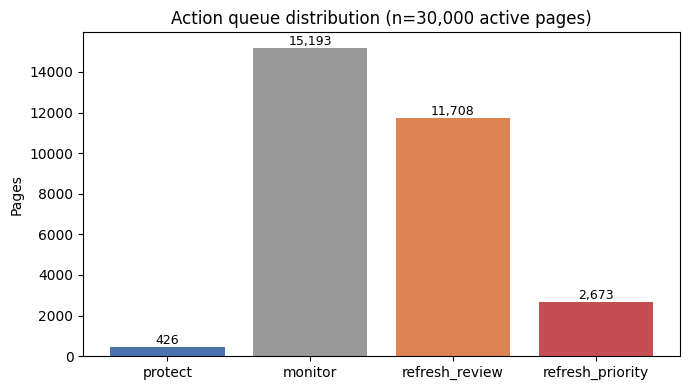


Saved figure -> ../figures/action_distribution.png


In [6]:
import os
import json
import matplotlib.pyplot as plt

os.makedirs("../outputs", exist_ok=True)
os.makedirs("../figures", exist_ok=True)

# ── 1. full ranked queue CSV (data file -- stays out of git by design) ────
export_cols = ["content_id", "client_id", "content_type", "position_tier", "freshness_tier",
               "action", "reason_codes", "decline_proba", "priority_score", "value_proxy_usd",
               "impressions_90d", "clicks_90d", "days_since_last_update"]

full_queue = df[export_cols].sort_values(
    ["action", "priority_score"], ascending=[True, False]
).reset_index(drop=True)

queue_path = "../outputs/action_playbook_queue.csv"
full_queue.to_csv(queue_path, index=False)
print(f"Wrote {len(full_queue):,} rows -> {queue_path} (gitignored by CI leak-guard, regenerate on demand)")

# ── 2. summary JSON (the receipts -- this one IS committed) ───────────────
action_counts = df["action"].value_counts().to_dict()
value_at_risk = df.loc[df["action"].isin(["refresh_priority", "refresh_review"]), "value_proxy_usd"].sum()

summary = {
    "generated_from": "content_refresh_anonymized.csv (30,000-row starter sample)",
    "model": {
        "type": "RandomForestClassifier(n_estimators=300, max_depth=10)",
        "split": "client-grouped holdout, same split as w05_model.ipynb / w06_validation_audit.ipynb",
        "validated_metrics": {"P@50": 0.560, "P@20": 0.500, "ROC_AUC": 0.661, "base_rate": 0.484},
    },
    "action_counts": {k: int(v) for k, v in action_counts.items()},
    "total_rows_scored": int(len(df)),
    "value_at_risk_usd": round(float(value_at_risk), 2),
    "value_proxy_formula": "clicks_90d * cpc (not impressions * cpc -- impressions aren't billable)",
    "reason_codes_used": REASON_COLS,
}

summary_path = "../outputs/action_summary.json"
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)
print(f"Wrote summary -> {summary_path}")
print(json.dumps(summary, indent=2))

# ── 3. figure: action distribution (committed to work/figures/) ───────────
fig, ax = plt.subplots(figsize=(7, 4))
order = ["protect", "monitor", "refresh_review", "refresh_priority"]
counts = [action_counts.get(a, 0) for a in order]
colors = ["#4C72B0", "#999999", "#DD8452", "#C44E52"]
ax.bar(order, counts, color=colors)
for i, c in enumerate(counts):
    ax.text(i, c + max(counts) * 0.01, f"{c:,}", ha="center", fontsize=9)
ax.set_ylabel("Pages")
ax.set_title(f"Action queue distribution (n={len(df):,} active pages)")
plt.tight_layout()

fig_path = "../figures/action_distribution.png"
plt.savefig(fig_path, dpi=120)
plt.show()
print(f"\nSaved figure -> {fig_path}")


## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Ranked actions with reason codes, built on the honest client-grouped model
- [x] Intended use, evidence base, and validity limits stated explicitly
- [x] Human review checklist + an explicit no-go list of what must never be automated
- [x] Monitoring/retrain triggers listed with a watch signal and an action for each
- [x] Queue exported to `work/outputs/` (gitignored); summary JSON + figure committed for the paper
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
